In [11]:
import pandas as pd
from commute_analysis import synthetic_population
base_dir = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"


In [4]:
# download the population grid data, save it to raw/data and load it into a pandas dataframe
df = synthetic_population.download_population_grid()
print(df.head())

                   GITTER_ID_100m  x_mp_100m  y_mp_100m  Einwohner
0  CRS3035RES100mN2689100E4337000    4337050    2689150          4
1  CRS3035RES100mN2689100E4341100    4341150    2689150         11
2  CRS3035RES100mN2690800E4341200    4341250    2690850          4
3  CRS3035RES100mN2691200E4341200    4341250    2691250         12
4  CRS3035RES100mN2691300E4341200    4341250    2691350          3


In [2]:
# read the population_grid.csv file from deutschlandticket-commute-analysis/data/raw/population_grid.csv and load it into a pandas dataframe
from pathlib import Path
import geopandas as gpd

base_dir = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"
df = pd.read_csv(Path(base_dir) / "data" / "raw" / "population_grid.csv")

# transform this dataframe into a geopandas dataframe with a geometry column that contains the centroid of the grid cell
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["x_mp_100m"], df["y_mp_100m"]),
    crs="EPSG:3035",
)

gdf.head()
print('y_mp_100m' in gdf.columns)

True


In [3]:
# create a geopandas.GeoDataFrame target_area that filters a circular area of 30 km radius around the center point (53.686439, 10.046120)
import geopandas as gpd
from shapely.geometry import Point

def create_target_area(center_lat, center_lon, radius_km):
    center = Point(center_lon, center_lat)

    target_area = gpd.GeoDataFrame(
        geometry=[center],
        crs="EPSG:4326",
    )

    # Accurate metric projection for Hamburg / northern Germany
    target_area = target_area.to_crs("EPSG:25832")

    target_area["geometry"] = target_area.geometry.buffer(
        radius_km * 1000
    )

    return target_area

CENTER_LAT = 53.686439
CENTER_LON = 10.046120
radius_km = 50
WORKPLACE = (53.686439, 10.046120)

target_area = create_target_area(CENTER_LAT, CENTER_LON, radius_km)

In [4]:
# create random employee sample of 1000 employees with random home locations within the target area
import numpy as np
gaussian_scale=12_000
samples = synthetic_population.sample_population_weighted_locations(gdf, "Einwohner", 10, target_area=target_area, filter_mode="gaussian", gaussian_scale=gaussian_scale)

In [5]:
import matplotlib.pyplot as plt
import contextily as cx

In [6]:
from matplotlib.axes import Axes

def plot_sampling_probability_map(
    probability_grid: gpd.GeoDataFrame,
    target_area: gpd.GeoDataFrame | None = None,
    center_point: gpd.GeoDataFrame | None = None,
    samples: gpd.GeoDataFrame | None = None,
    ax: Axes | None = None,
    title: str = "Synthetic employee sampling probability",
    cmap: str = "viridis",
    show_legend: bool = True,
) -> Axes:
    """
    Plot the sampling probability assigned to each grid cell.

    Parameters
    ----------
    probability_grid : geopandas.GeoDataFrame
        Grid returned by calculate_sampling_probability_grid().
    target_area : geopandas.GeoDataFrame, optional
        Boundary to draw around the sampling region.
    center_point : geopandas.GeoDataFrame, optional
        Workplace or Gaussian center point.
    samples : geopandas.GeoDataFrame, optional
        Generated sample points to overlay.
    ax : matplotlib.axes.Axes, optional
        Existing Matplotlib axis.
    title : str
        Plot title.
    cmap : str
        Matplotlib colour map.
    show_legend : bool
        Whether to show the probability legend.

    Returns
    -------
    matplotlib.axes.Axes
        The axis containing the plot.
    """
    if "sampling_probability" not in probability_grid.columns:
        raise KeyError(
            "probability_grid must contain "
            "'sampling_probability'."
        )

    if probability_grid.crs is None:
        raise ValueError(
            "probability_grid must have a CRS."
        )

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))

    probability_grid.plot(
        ax=ax,
        column="sampling_probability",
        cmap=cmap,
        legend=show_legend,
        linewidth=0,
        legend_kwds={
            "label": "Probability of selecting grid cell",
            "shrink": 0.7,
        },
    )

    if target_area is not None:
        target_area.to_crs(
            probability_grid.crs
        ).boundary.plot(
            ax=ax,
            linewidth=1.5,
            label="Target area",
        )

    if samples is not None:
        samples.to_crs(
            probability_grid.crs
        ).plot(
            ax=ax,
            markersize=12,
            marker="o",
            facecolor="none",
            edgecolor="white",
            linewidth=0.7,
            label="Sampled employees",
        )

    if center_point is not None:
        center_point.to_crs(
            probability_grid.crs
        ).plot(
            ax=ax,
            marker="*",
            markersize=180,
            color="red",
            edgecolor="white",
            linewidth=0.8,
            label="Workplace",
            zorder=5,
        )

    ax.set_title(title)
    ax.set_axis_off()

    if any(
        item is not None
        for item in [target_area, samples, center_point]
    ):
        ax.legend()

    return ax

  employee_id  source_population  source_probability  distance_weight  \
0   EMP-00001              195.0            0.000074         0.460723   
1   EMP-00002               18.0            0.000010         0.637005   
2   EMP-00003               55.0            0.000036         0.789909   
3   EMP-00004              384.0            0.000184         0.576772   
4   EMP-00005               22.0            0.000003         0.162615   

                  geometry  
0  POINT (4324950 3382750)  
1  POINT (4334950 3394350)  
2  POINT (4323350 3389450)  
3  POINT (4326150 3385250)  
4  POINT (4312750 3417550)  
       sampling_probability  cell_area_km2  probability_density_km2
count          1.089280e+05   1.089280e+05            108928.000000
mean           9.180376e-06   1.000000e-06                 9.180376
std            2.086405e-05   4.235184e-22                20.864050
min            4.241681e-10   1.000000e-06                 0.000424
25%            4.100174e-08   1.000000e-06     

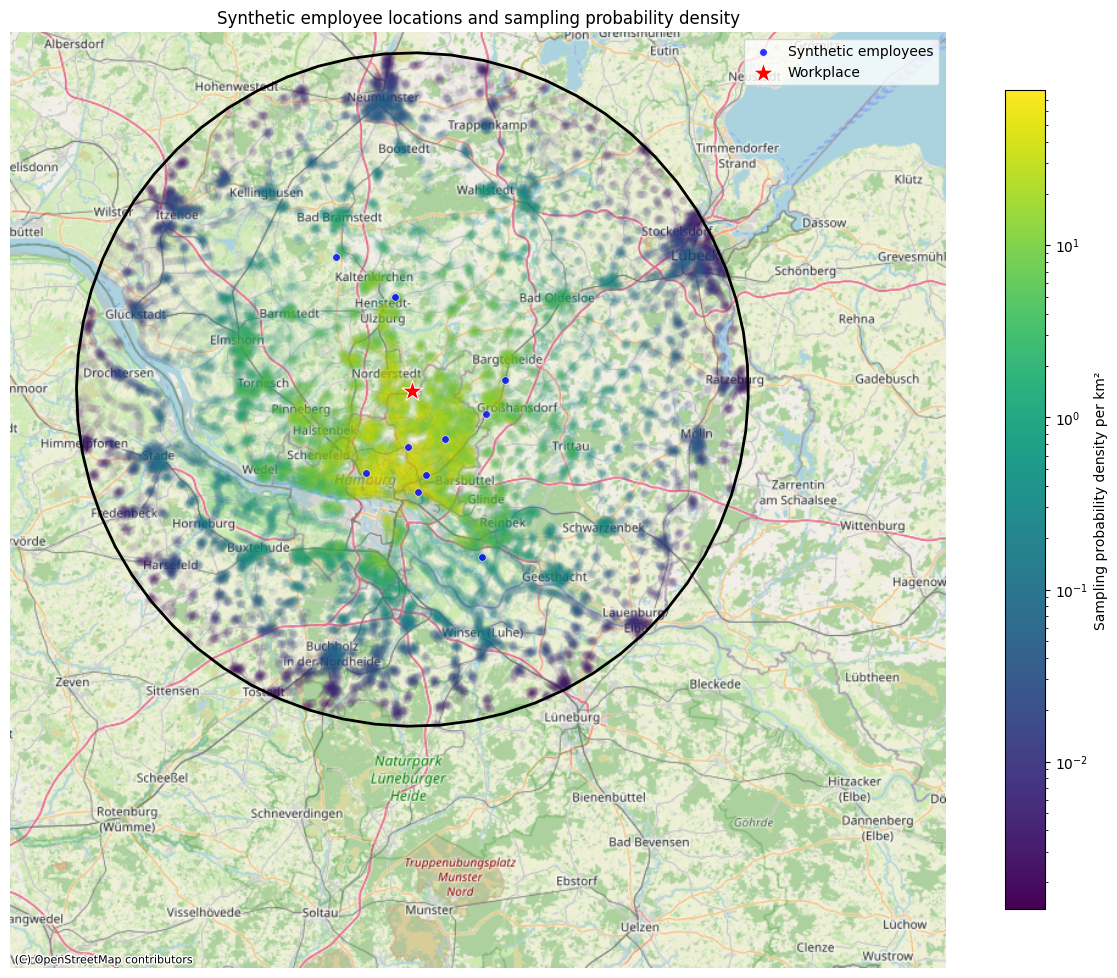

In [7]:
print(samples.head())
# create a map visualization of the points in the samples geodataframe and the probability density using geopandas and matplotlib

from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# 1. Calculate sampling probabilities
# ------------------------------------------------------------

probability_grid = (
    synthetic_population.calculate_sampling_probability_grid(
        population_grid=gdf,
        population_column="Einwohner",
        target_area=target_area,
        filter_mode="gaussian",
        gaussian_scale=gaussian_scale,
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Calculate density in a metre-based CRS
# ------------------------------------------------------------

# EPSG:3035 is particularly suitable for European area calculations.
probability_projected = probability_grid.to_crs("EPSG:3035")

probability_projected["cell_area_km2"] = (
    1 / 1_000_000
)

probability_projected["probability_density_km2"] = (
    probability_projected["sampling_probability"]
    / probability_projected["cell_area_km2"]
)

# Remove invalid values
probability_projected["probability_density_km2"] = (
    probability_projected["probability_density_km2"]
    .replace([np.inf, -np.inf], np.nan)
)

probability_projected = probability_projected.dropna(
    subset=["probability_density_km2"]
)


# ------------------------------------------------------------
# 3. Inspect the values
# ------------------------------------------------------------

print(
    probability_projected[
        [
            "sampling_probability",
            "cell_area_km2",
            "probability_density_km2",
        ]
    ].describe()
)

print(
    "Positive-density cells:",
    (probability_projected["probability_density_km2"] > 0).sum(),
)


# ------------------------------------------------------------
# 4. Convert plotting layers to Web Mercator
# ------------------------------------------------------------

probability_web = probability_projected.to_crs("EPSG:3857")
samples_web = samples.to_crs("EPSG:3857")
area_web = target_area.to_crs("EPSG:3857")

center_point = gpd.GeoDataFrame(
    {"name": ["Workplace"]},
    geometry=[Point(WORKPLACE[1], WORKPLACE[0])],
    crs="EPSG:4326",
).to_crs("EPSG:3857")


# Only positive values can be displayed with LogNorm
density_to_plot = probability_web[
    probability_web["probability_density_km2"] > 0
].copy()

density_values = density_to_plot["probability_density_km2"]

# Ignore extreme outliers when setting the displayed colour range
vmin = density_values.quantile(0.02)
vmax = density_values.quantile(0.98)

if vmin <= 0 or vmin == vmax:
    norm = None
else:
    norm = LogNorm(vmin=vmin, vmax=vmax)


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 12))


# Set map extent before adding the basemap
min_x, min_y, max_x, max_y = area_web.total_bounds
padding = 2_000

ax.set_xlim(min_x - padding, max_x + padding)
ax.set_ylim(min_y - padding, max_y + padding)


# Add basemap first
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,
    crs=probability_web.crs,
    reset_extent=False,
    zorder=0,
)


# Probability-density grid
density_to_plot.plot(
    ax=ax,
    column="probability_density_km2",
    cmap="viridis",
    norm=norm,
    alpha=0.02,
    edgecolor="none",
    legend=True,
    zorder=1,
    legend_kwds={
        "label": "Sampling probability density per km²",
        "shrink": 0.7,
    },
)


# Target-area boundary
area_web.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
    zorder=2,
)


# Employee samples
samples_web.plot(
    ax=ax,
    marker="o",
    color="blue",
    edgecolor="white",
    linewidth=0.5,
    markersize=30,
    alpha=0.8,
    zorder=3,
    label="Synthetic employees",
)


# Workplace
center_point.plot(
    ax=ax,
    color="red",
    edgecolor="white",
    linewidth=0.8,
    marker="*",
    markersize=250,
    zorder=4,
    label="Workplace",
)


ax.set_title(
    "Synthetic employee locations and sampling probability density"
)

ax.legend(loc="upper right")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [8]:
# save the synthetic dataset to the data/processed directory as a geopackage file
output_path = Path(base_dir) / "data" / "processed" / "synthetic_employees.gpkg"
samples.to_file(output_path, layer="synthetic_employees", driver="GPKG")

In [9]:
# load the synthetic dataset from the data/processed directory as a geopackage file and plot it
synthetic_employees = gpd.read_file(output_path, layer="synthetic_employees")
print(synthetic_employees.head())

  employee_id  source_population  source_probability  distance_weight  \
0   EMP-00001              181.0            0.000056         0.621921   
1   EMP-00002               14.0            0.000003         0.405038   
2   EMP-00003               53.0            0.000019         0.715606   
3   EMP-00004               81.0            0.000037         0.933316   
4   EMP-00005               31.0            0.000013         0.835415   

                  geometry  
0  POINT (4331250 3379550)  
1  POINT (4338750 3375150)  
2  POINT (4328250 3381850)  
3  POINT (4318850 3392350)  
4  POINT (4320950 3409250)  


In [13]:
# create various synthetic datasets of emplyees with different target area sizes using both uniform filter and gaussian filter (with different guassian scales)
# and save them to the data/processed directory 



In [ ]:
# calculate commute distance for the first synthetic employee from the samples geodataframe to the center point (workplace) 
# using the r5py library; for now lets use the default r5py car routing

from commute_analysis import routing
import geopandas as geopandas

origin = (53.56407423036692, 9.992173763673405)
destination = (53.68624090313588, 10.046480574496965)
origin = (53.54849886836954, 9.945582869726552)
destination = (53.54946099368006, 9.959656286579415)
origin = samples.iloc[1].geometry
destination = WORKPLACE

departure_time = "2026-09-22T07:10:00"  # ISO 8601 format
# distance, time, route = routing.route_between_points(origin, destination, transport_modes=["car"], data_dir=Path(base_dir) / "data" / "raw" / "osm", crs="EPSG:4326")

distance, time, route = routing.route_between_points(origin, destination, transport_modes=["car"], data_dir=Path(base_dir) / "data" / "raw" / "osm", crs=samples.crs, departure_time=departure_time)
print(f"Distance: {distance:.2f} km, Time: {time:.2f} minutes")

origin_gdf = geopandas.GeoDataFrame(
        {
            "id": [1],
            "geometry": origin
        },
        crs=samples.crs,
)
origin = origin_gdf.to_crs("EPSG:4326").geometry.iloc[0]

Distance: 16.07 km, Time: 36.88 minutes


: 

In [ ]:
# EXPERIMENTAL

import datetime
import r5py
from commute_analysis import routing
import geopandas as geopandas
from shapely.geometry import Point

origin = (53.56407423036692, 9.992173763673405)
origin_gdf = geopandas.GeoDataFrame(
        {
            "id": [1],
            "geometry": Point(origin[1], origin[0])
        },
        crs="EPSG:4326",
)
destination = (53.68624090313588, 10.046480574496965)
destination_gdf = geopandas.GeoDataFrame(
        {
            "id": [1],
            "geometry": Point(destination[1], destination[0])
        },
        crs="EPSG:4326",
)
data_dir = Path(base_dir) / "data" / "raw" / "osm"
transport_network = routing.build_transport_network(data_dir=data_dir, allow_errors=True)

detailed_itineraries = r5py.DetailedItineraries(
    transport_network,
    origins=origin_gdf,
    destinations=destination_gdf,
    departure=datetime.datetime(2026, 9, 22, 8, 30),
    transport_modes=[r5py.TransportMode.TRANSIT, r5py.TransportMode.WALK],
    snap_to_network=True,
)

In [52]:
print(detailed_itineraries.iloc[1:5])
route = detailed_itineraries.iloc[1:5]
route1 = detailed_itineraries.iloc[1:2]
route2 = detailed_itineraries.iloc[2:3]
route3 = detailed_itineraries.iloc[3:4]
route4 = detailed_itineraries.iloc[4:5]
route5 = detailed_itineraries.iloc[5:6]
route6 = detailed_itineraries.iloc[6:7]
route7 = detailed_itineraries.iloc[7:8]

   from_id  to_id  option  segment      transport_mode      departure_time  \
1        1      1       1        0  TransportMode.WALK 2026-09-22 08:32:12   
2        1      1       1        1  TransportMode.RAIL 2026-09-22 08:52:00   
3        1      1       1        2  TransportMode.WALK 2026-09-22 09:20:00   
4        1      1       1        3   TransportMode.BUS 2026-09-22 09:25:00   

       distance     travel_time       wait_time                          feed  \
1    705.057000 0 days 00:11:59 0 days 00:00:00                          None   
2  16376.808010 0 days 00:27:00 0 days 00:01:17  hvv_Rohdaten_GTFS_Fpl_26.ZIP   
3     56.849000 0 days 00:01:00 0 days 00:01:07                          None   
4   3436.736251 0 days 00:08:00 0 days 00:04:53  hvv_Rohdaten_GTFS_Fpl_26.ZIP   

  agency_id  route_id start_stop_id end_stop_id  \
1      None      None          None        None   
2        76  1466_402            de          de   
3      None      None          None        None   

In [57]:
print(samples.iloc[0].geometry)
print(type(route))
print(route)


POINT (4326650 3389650)
<class 'r5py.r5.detailed_itineraries.DetailedItineraries'>


In [36]:
print(type(origin))

<class 'shapely.geometry.point.Point'>


In [30]:
print(results)
print(results[0]["geometry"][2])

[     from_id  to_id  option  segment      transport_mode      departure_time  \
0          0      1       0        0  TransportMode.WALK                 NaT   
1          0      1       1        0  TransportMode.WALK 2026-06-01 08:02:47   
2          0      1       1        1   TransportMode.BUS 2026-06-01 08:20:00   
3          0      1       1        2  TransportMode.WALK 2026-06-01 08:31:00   
4          0      1       1        3   TransportMode.BUS 2026-06-01 08:41:00   
..       ...    ...     ...      ...                 ...                 ...   
296        0      1      60        0  TransportMode.WALK 2026-06-01 08:05:59   
297        0      1      60        1   TransportMode.BUS 2026-06-01 08:32:00   
298        0      1      60        2  TransportMode.WALK 2026-06-01 08:44:00   
299        0      1      60        3   TransportMode.BUS 2026-06-01 08:51:00   
300        0      1      60        4  TransportMode.WALK 2026-06-01 09:03:00   

        distance     travel_time      

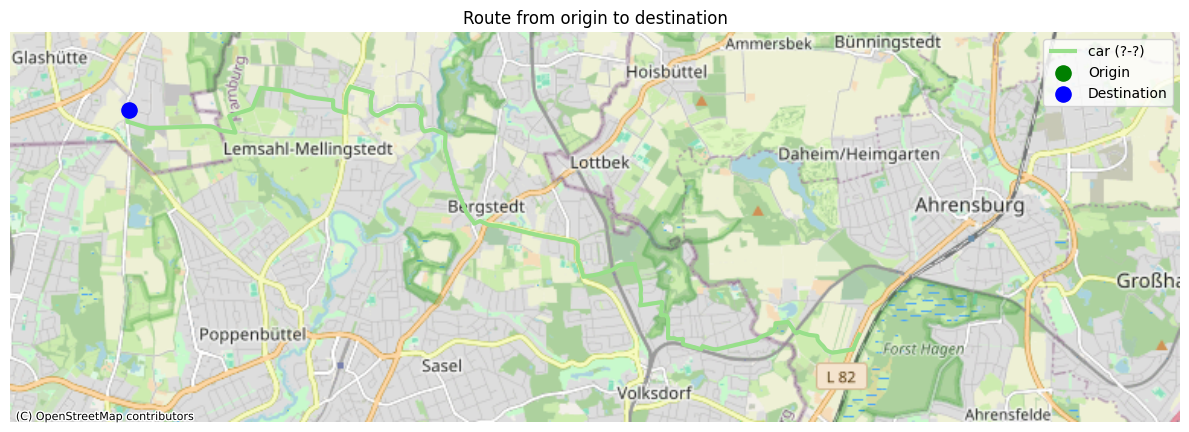

In [15]:
# plot the route on a map using geopandas and matplotlib
import matplotlib.pyplot as plt
import contextily as cx

if route is not None and not route.empty:
    route_web = route.to_crs("EPSG:3857")

    fig, ax = plt.subplots(figsize=(12, 12))

    # Build map extent around the route and endpoints
    if route_web.geometry.notna().any():
        bounds = route_web.total_bounds
        padding = 1_000
        ax.set_xlim(bounds[0] - padding, bounds[2] + padding)
        ax.set_ylim(bounds[1] - padding, bounds[3] + padding)
    else:
        min_lon = min(origin[1], destination[1])
        min_lat = min(origin[0], destination[0])
        max_lon = max(origin[1], destination[1])
        max_lat = max(origin[0], destination[0])
        ax.set_xlim(min_lon, max_lon)
        ax.set_ylim(min_lat, max_lat)

    cx.add_basemap(
        ax,
        source=cx.providers.OpenStreetMap.Mapnik,
        crs=route_web.crs,
        reset_extent=False,
        zorder=0,
    )

    route_web = route_web.copy()
    route_web["departure_time_dt"] = pd.to_datetime(route_web["departure_time"], errors="coerce")
    route_web["travel_time_dt"] = pd.to_timedelta(route_web["travel_time"], errors="coerce")
    route_web["arrival_time_dt"] = route_web["departure_time_dt"] + route_web["travel_time_dt"]

    cmap = plt.cm.tab20
    # for idx, row in route_web.iterrows():
    #     geometry = row["geometry"]
    #     if geometry is None or getattr(geometry, "is_empty", False):
    #         continue

    #     mode_name = str(row.get("transport_mode", "")).split(".")[-1].lower()
    #     departure_label = (
    #         pd.Timestamp(row["departure_time_dt"]).strftime("%H:%M")
    #         if pd.notna(row["departure_time_dt"])
    #         else "?"
    #     )
    #     arrival_label = (
    #         pd.Timestamp(row["arrival_time_dt"]).strftime("%H:%M")
    #         if pd.notna(row["arrival_time_dt"])
    #         else "?"
    #     )
    #     label = f"{mode_name} ({departure_label}-{arrival_label})"

    #     route_web.iloc[[idx]].plot(
    #         ax=ax,
    #         color=cmap(idx % 20),
    #         linewidth=3,
    #         zorder=2,
    #         label=label,
    #     )
    for plot_idx, (_, row) in enumerate(route_web.iterrows()):
        geometry = row["geometry"]

        if geometry is None or geometry.is_empty:
            continue

        mode_name = str(row.get("transport_mode", "")).split(".")[-1].lower()

        departure_label = (
            row["departure_time_dt"].strftime("%H:%M")
            if pd.notna(row["departure_time_dt"])
            else "?"
        )

        arrival_label = (
            row["arrival_time_dt"].strftime("%H:%M")
            if pd.notna(row["arrival_time_dt"])
            else "?"
        )

        label = f"{mode_name} ({departure_label}-{arrival_label})"

        gpd.GeoSeries(
            [geometry],
            crs=route_web.crs,
        ).plot(
            ax=ax,
            color=cmap((plot_idx + 5) % 10),
            linewidth=3,
            zorder=2,
            label=label,
        )

    origin_crs = "EPSG:4326"
    if type(origin) is Point:
        origin = (origin.y, origin.x)
        origin_crs = samples.crs

    origin_gdf = gpd.GeoDataFrame(
        {"name": ["Origin"]},
        geometry=[Point(origin[1], origin[0])],
        crs=origin_crs,
    ).to_crs("EPSG:3857")

    if type(destination) is Point:
        destination = (destination.y, destination.x)

    destination_gdf = gpd.GeoDataFrame(
        {"name": ["Destination"]},
        geometry=[Point(destination[1], destination[0])],
        crs="EPSG:4326",
    ).to_crs("EPSG:3857")

    origin_gdf.plot(ax=ax, marker="o", color="green", markersize=120, zorder=3, label="Origin")
    destination_gdf.plot(ax=ax, marker="o", color="blue", markersize=120, zorder=3, label="Destination")

    ax.set_title("Route from origin to destination")
    ax.set_axis_off()
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("No route geometry was returned from the routing function.")


In [10]:
import folium
import pandas as pd
from shapely.geometry import Point
from pathlib import Path
from branca.element import Element

if route is None or route.empty:
    print("No route geometry was returned from the routing function.")

route_df = route.copy()
route_df["departure_time_dt"] = pd.to_datetime(route_df["departure_time"], errors="coerce")
route_df["travel_time_dt"] = pd.to_timedelta(route_df["travel_time"], errors="coerce")
route_df["arrival_time_dt"] = route_df["departure_time_dt"] + route_df["travel_time_dt"]

route_gdf = route_df.to_crs("EPSG:4326")
route_gdf = route_gdf.rename(columns={"transport_mode": "mode"})

center_lon = route_gdf.geometry.centroid.x.mean()
center_lat = route_gdf.geometry.centroid.y.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")

# Resolve origin/destination points for markers
if isinstance(origin, Point):
    origin_point = [origin.y, origin.x]
else:
    origin_point = [origin[0], origin[1]]

if isinstance(destination, Point):
    destination_point = [destination.y, destination.x]
else:
    destination_point = [destination[0], destination[1]]

folium.Marker(origin_point, tooltip="Origin", icon=folium.Icon(color="green", icon="home")).add_to(m)
folium.Marker(destination_point, tooltip="Destination", icon=folium.Icon(color="blue", icon="flag")).add_to(m)

colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]

# Collect legend entries and draw segments
legend_entries = []
seen_labels = set()
for idx, row in route_gdf.iterrows():
    geometry = row["geometry"]
    if geometry is None or getattr(geometry, "is_empty", False):
        continue

    mode_name = str(row.get("mode", "")).split(".")[-1].lower()
    departure_label = (
        pd.Timestamp(row["departure_time_dt"]).strftime("%H:%M")
        if pd.notna(row["departure_time_dt"])
        else "?"
    )
    arrival_label = (
        pd.Timestamp(row["arrival_time_dt"]).strftime("%H:%M")
        if pd.notna(row["arrival_time_dt"])
        else "?"
    )
    label = f"{mode_name} ({departure_label}-{arrival_label})"
    color = colors[idx % len(colors)]

    if label not in seen_labels:
        legend_entries.append((color, label))
        seen_labels.add(label)

    # Extract coordinates robustly for LineString or MultiLineString
    coords = []
    if hasattr(geometry, "geoms"):
        for part in geometry.geoms:
            coords.extend(list(part.coords))
    else:
        coords = list(geometry.coords)

    if len(coords) >= 2:
        folium.PolyLine(
            [(lat, lon) for lon, lat in coords],
            color=color,
            weight=5,
            opacity=0.9,
            tooltip=label,
        ).add_to(m)

# Build HTML legend to match matplotlib legend
entries_html = "".join(
    f"<div style='display:flex;align-items:center;margin-bottom:4px;'>"
    f"<span style='display:inline-block;width:14px;height:14px;background:{col};margin-right:8px;border:1px solid #444;'></span>"
    f"{lab}</div>"
    for col, lab in legend_entries
)

legend_html = f"""
<div style="position: fixed; bottom: 50px; left: 50px; z-index:9999; background: white; padding: 10px; border: 2px solid grey; border-radius: 6px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3); max-height: 300px; overflow:auto;">
  <h4 style="margin:0 0 6px 0;">Itinerary segments</h4>
  {entries_html}
</div>
"""

m.get_root().html.add_child(Element(legend_html))

# Save interactive map to outputs
m.save(Path(base_dir) / "outputs" / "route_map.html")

m


/tmp/ipykernel_106695/3672075120.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = route_gdf.geometry.centroid.x.mean()
/tmp/ipykernel_106695/3672075120.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = route_gdf.geometry.centroid.y.mean()


/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/geopandas/plotting.py:962: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/geopandas/plotting.py:962: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)
/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis/.venv/lib/python3.10/site-packages/geopandas/plotting.py:962: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)
/tmp/ipykernel_106695/2619911651.py:174: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://

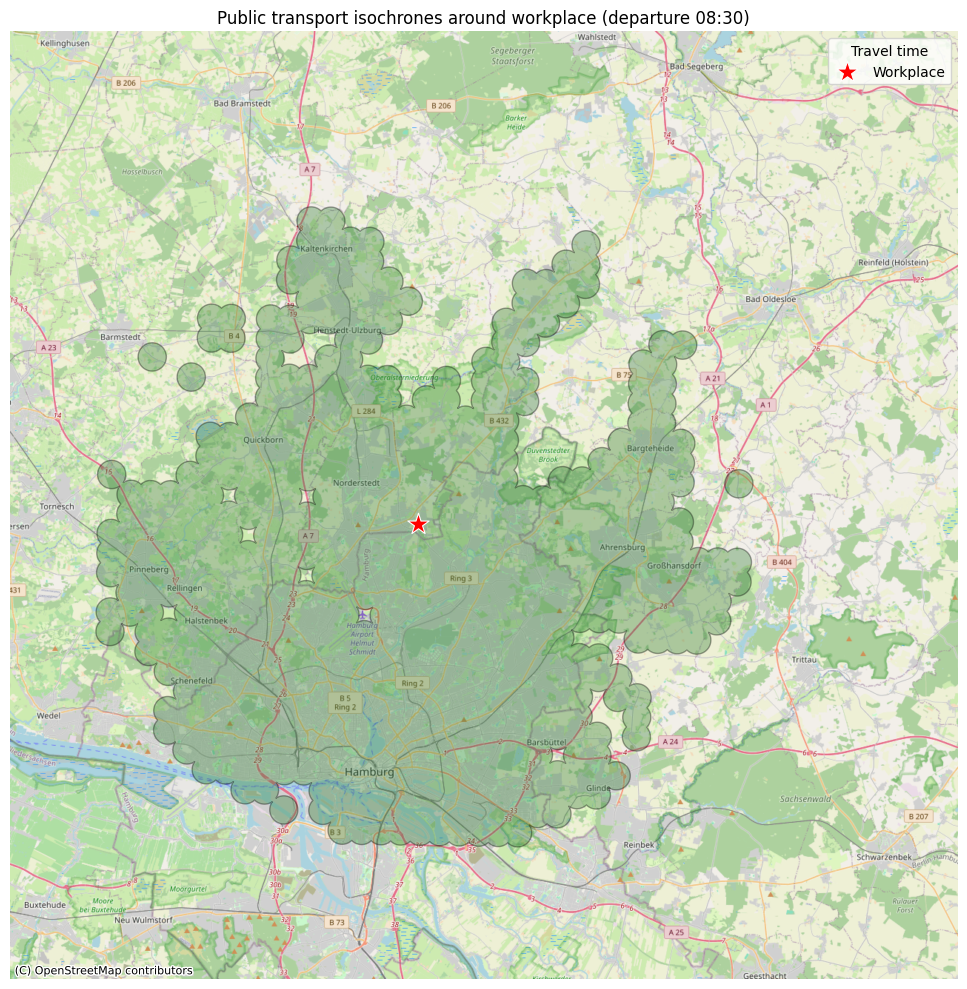

In [13]:
# Compute and plot public-transport isochrones around the workplace using r5py.
import datetime
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r5py
from shapely.geometry import Point

from commute_analysis import routing

if "base_dir" not in globals():
    base_dir = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"
if "WORKPLACE" not in globals():
    WORKPLACE = (53.686439, 10.046120)

# Build transport network from local OSM + GTFS data.
data_dir = Path(base_dir) / "data" / "raw" / "osm"
transport_network = routing.build_transport_network(data_dir=data_dir, allow_errors=True)

# Origin is the workplace point.
workplace_origin = gpd.GeoDataFrame(
    {"id": [1]},
    geometry=[Point(WORKPLACE[1], WORKPLACE[0])],
    crs="EPSG:4326",
)

# Build a regular destination grid around workplace in meters (EPSG:25832).
analysis_radius_m = 20_000
grid_step_m = 1_200

origin_25832 = workplace_origin.to_crs("EPSG:25832")
origin_x, origin_y = origin_25832.geometry.iloc[0].x, origin_25832.geometry.iloc[0].y

xs = np.arange(origin_x - analysis_radius_m, origin_x + analysis_radius_m + grid_step_m, grid_step_m)
ys = np.arange(origin_y - analysis_radius_m, origin_y + analysis_radius_m + grid_step_m, grid_step_m)

destination_points = []
destination_ids = []
for ix, x in enumerate(xs):
    for iy, y in enumerate(ys):
        pt = Point(x, y)
        if pt.distance(origin_25832.geometry.iloc[0]) <= analysis_radius_m:
            destination_points.append(pt)
            destination_ids.append(len(destination_ids) + 1)

destinations_25832 = gpd.GeoDataFrame(
    {"id": destination_ids},
    geometry=destination_points,
    crs="EPSG:25832",
)
destinations = destinations_25832.to_crs("EPSG:4326")

departure_dt = datetime.datetime(2026, 9, 22, 8, 30)

# Compute public-transport travel time matrix from workplace to destination grid points.
ttm = r5py.TravelTimeMatrix(
    transport_network,
    origins=workplace_origin,
    destinations=destinations,
    departure=departure_dt,
    transport_modes=[r5py.TransportMode.TRANSIT, r5py.TransportMode.WALK],
    snap_to_network=True,
)

if ttm.empty:
    print("No travel-time results returned for public transport.")
else:
    ttm = ttm.copy()

    if "travel_time" in ttm.columns:
        if pd.api.types.is_timedelta64_dtype(ttm["travel_time"]):
            ttm["travel_time_min"] = ttm["travel_time"].dt.total_seconds() / 60.0
        else:
            parsed = pd.to_timedelta(ttm["travel_time"], errors="coerce")
            if parsed.notna().any():
                ttm["travel_time_min"] = parsed.dt.total_seconds() / 60.0
            else:
                ttm["travel_time_min"] = pd.to_numeric(ttm["travel_time"], errors="coerce")
    else:
        raise KeyError("TravelTimeMatrix output does not contain a 'travel_time' column.")

    reachable = ttm[ttm["travel_time_min"].notna()].copy()
    reachable = reachable[reachable["travel_time_min"] <= 60].copy()

    if reachable.empty:
        print("No destinations reachable within 60 minutes by public transport.")
    else:
        grid_with_times = destinations.merge(
            reachable[["to_id", "travel_time_min"]],
            left_on="id",
            right_on="to_id",
            how="inner",
        )

        # Build contiguous isochrone polygons by buffering reachable grid points and dissolving by time band.
        bins = [0, 15, 30, 45, 60]
        labels = ["0-15 min", "15-30 min", "30-45 min", "45-60 min"]
        grid_with_times["time_band"] = pd.cut(
            grid_with_times["travel_time_min"],
            bins=bins,
            labels=labels,
            include_lowest=True,
            right=True,
        )
        grid_with_times = grid_with_times.dropna(subset=["time_band"]).copy()

        grid_bands_25832 = grid_with_times.to_crs("EPSG:25832")
        isochrone_parts = gpd.GeoDataFrame(
            grid_bands_25832[["time_band"]].copy(),
            geometry=grid_bands_25832.buffer(grid_step_m * 0.72),
            crs="EPSG:25832",
        )
        isochrones = isochrone_parts.dissolve(by="time_band", as_index=False)

        # Plot in Web Mercator with basemap.
        plot_crs = "EPSG:3857"
        isochrones_web = isochrones.to_crs(plot_crs)
        workplace_web = workplace_origin.to_crs(plot_crs)

        fig, ax = plt.subplots(figsize=(12, 10))

        colors = {
            "0-15 min": "#2E7D32",
            "15-30 min": "#66BB6A",
            "30-45 min": "#FFCA28",
            "45-60 min": "#EF6C00",
        }
        plot_order = ["45-60 min", "30-45 min", "15-30 min", "0-15 min"]

        for band in plot_order:
            band_gdf = isochrones_web[isochrones_web["time_band"] == band]
            if not band_gdf.empty:
                band_gdf.plot(
                    ax=ax,
                    color=colors[band],
                    alpha=0.35,
                    edgecolor="black",
                    linewidth=1.0,
                    label=band,
                    zorder=2,
                )

        workplace_web.plot(
            ax=ax,
            marker="*",
            color="red",
            edgecolor="white",
            linewidth=0.8,
            markersize=260,
            label="Workplace",
            zorder=4,
        )

        minx, miny, maxx, maxy = isochrones_web.total_bounds
        pad_x = max((maxx - minx) * 0.04, 750)
        pad_y = max((maxy - miny) * 0.04, 750)
        ax.set_xlim(minx - pad_x, maxx + pad_x)
        ax.set_ylim(miny - pad_y, maxy + pad_y)

        cx.add_basemap(
            ax,
            source=cx.providers.OpenStreetMap.Mapnik,
            crs=plot_crs,
            reset_extent=False,
            zorder=1,
        )

        ax.set_title("Public transport isochrones around workplace (departure 08:30)")
        ax.set_axis_off()
        ax.legend(title="Travel time", loc="upper right")
        plt.tight_layout()
        plt.show()